# 공급망 배송 지연 리스크 분석
## STEP 2 — 데이터 전처리 (Preprocessing)

**전처리 목표**  
EDA에서 파악한 문제점을 바탕으로 모델링에 바로 사용할 수 있는 깔끔한 데이터를 만든다.

**전처리 순서**  
1. 데이터 불러오기  
2. 불필요한 컬럼 제거  
3. 결측치 처리  
4. 날짜 변수에서 파생 변수 생성  
5. 범주형 변수 인코딩  
6. 이상치 확인  
7. 최종 데이터셋 저장

---
## 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import matplotlib.font_manager as fm
import os

warnings.filterwarnings('ignore')

# 그래프 기본 스타일 설정
sns.set_style('whitegrid')

# 한글 폰트 설정
font_regular = 'C:/Windows/Fonts/malgun.ttf'     # 맑은 고딕 Regular
font_bold = 'C:/Windows/Fonts/malgunbd.ttf'      # 맑은 고딕 Bold

# 폰트 파일 등록
if os.path.exists(font_regular):
    fm.fontManager.addfont(font_regular)

if os.path.exists(font_bold):
    fm.fontManager.addfont(font_bold)

# matplotlib 전체 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('라이브러리 및 한글 폰트 설정 완료')
print('현재 font.family:', plt.rcParams['font.family'])

라이브러리 및 한글 폰트 설정 완료
현재 font.family: ['Malgun Gothic']


---
## 1. 데이터 불러오기

In [2]:
from pathlib import Path

path_candidates = [
    Path('../data/raw/DataCoSupplyChainDataset.csv'),
    Path('data/raw/DataCoSupplyChainDataset.csv'),
    Path('DataCoSupplyChainDataset.csv'),
    Path('/mnt/data/DataCoSupplyChainDataset.csv'),
]

for path in path_candidates:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError('DataCoSupplyChainDataset.csv 파일을 찾을 수 없습니다. data/raw 폴더에 원본 데이터를 넣어주세요.')

df = pd.read_csv(data_path, encoding='latin1')

print(f'데이터 경로: {data_path}')
print(f'원본 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}컬럼')


데이터 경로: ..\data\raw\DataCoSupplyChainDataset.csv
원본 데이터 크기: 180,519행 × 53컬럼


---
## 2. 불필요한 컬럼 제거

아래 기준으로 컬럼을 제거한다.

| 제거 기준 | 해당 컬럼 |
|-----------|----------|
| 개인정보 (모델에 의미 없음) | 이름, 이메일, 비밀번호, 주소 등 |
| 결측치 과다 (86% 이상) | Order Zipcode, Product Description |
| 타겟 변수와 직접 연결 (데이터 누수) | Delivery Status |
| 중복 정보 | Product Image, Product Card Id 등 ID 계열 |
| 분석 목적과 무관 | 위경도 좌표 등 |

In [3]:
# 제거할 컬럼 목록
drop_cols = [
    # 개인정보
    'Customer Email', 'Customer Fname', 'Customer Lname',
    'Customer Password', 'Customer Street', 'Customer Zipcode',

    # 결측치 과다
    'Product Description', 'Order Zipcode',

    # 타겟 변수와 직접 연결 → 이 컬럼을 넣으면 모델이 너무 쉽게 맞춰버림 (데이터 누수)
    'Delivery Status',

    # 이미지 URL — 분석에 불필요
    'Product Image',

    # ID 계열 — 모델 피처로 의미 없음
    'Order Id', 'Order Item Id', 'Order Customer Id',
    'Customer Id', 'Product Card Id', 'Order Item Cardprod Id',
    'Category Id', 'Department Id', 'Product Category Id',

    # 위경도 — 지역 정보는 Market, Order Region으로 대체
    'Latitude', 'Longitude',
]

df = df.drop(columns=drop_cols)

print(f'컬럼 제거 후: {df.shape[0]:,}행 × {df.shape[1]}컬럼')
print(f'제거된 컬럼 수: {len(drop_cols)}개')
print()
print('남은 컬럼 목록:')
for col in df.columns:
    print(f'  - {col}')

컬럼 제거 후: 180,519행 × 32컬럼
제거된 컬럼 수: 21개

남은 컬럼 목록:
  - Type
  - Days for shipping (real)
  - Days for shipment (scheduled)
  - Benefit per order
  - Sales per customer
  - Late_delivery_risk
  - Category Name
  - Customer City
  - Customer Country
  - Customer Segment
  - Customer State
  - Department Name
  - Market
  - Order City
  - Order Country
  - order date (DateOrders)
  - Order Item Discount
  - Order Item Discount Rate
  - Order Item Product Price
  - Order Item Profit Ratio
  - Order Item Quantity
  - Sales
  - Order Item Total
  - Order Profit Per Order
  - Order Region
  - Order State
  - Order Status
  - Product Name
  - Product Price
  - Product Status
  - shipping date (DateOrders)
  - Shipping Mode


---
## 3. 결측치 처리

In [4]:
# 남아있는 결측치 확인
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('결측치 없음 — 추가 처리 불필요')
else:
    print('남아있는 결측치:')
    print(missing)
    print()

    # Customer Lname은 개인정보라 이미 제거 대상이었고
    # 남아있다면 해당 행만 제거
    before = len(df)
    df = df.dropna()
    after = len(df)
    print(f'결측치 행 제거: {before - after}행 제거됨')

print(f'\n최종 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}컬럼')

결측치 없음 — 추가 처리 불필요

최종 데이터 크기: 180,519행 × 32컬럼


---
## ⚠️ 데이터 누수(Data Leakage) 주의

아래 변수는 **배송이 완료된 후에야 알 수 있는 정보**이거나 타겟과 직접 연결된 정보라서 모델에 넣으면 안 된다.  
주문 시점에 예측하는 모델이 목표이므로, 미래 정보가 섞이면 실전에서 쓸 수 없는 모델이 된다.

| 제거 변수 | 이유 |
|-----------|------|
| `Days for shipping (real)` | 실제 배송 소요일 — 배송 완료 후 확인 가능 |
| `Delivery Status` | 배송 결과 상태 — 타겟과 직접 연결 |
| `shipping_delay` | 실제일 - 예정일 — 배송 완료 후에만 계산 가능 |

`Delivery Status`는 앞선 컬럼 제거 단계에서 제거했고, `Days for shipping (real)`은 안전한 피처 목록에서 제외한다.


---
## 4. 안전한 피처 선택 및 날짜 파생 변수 생성

누수 가능성이 있는 컬럼을 제거하고,  
주문 시점에 알 수 있는 정보만으로 피처를 구성한다.

In [5]:
# 주문 시점에 알 수 있는 피처만 사용 (데이터 누수 방지)
safe_cols = [
    'Type',                           # 결제 방식
    'Days for shipment (scheduled)',   # 예정 배송일 (주문 시 확정되는 값)
    'Benefit per order',              # 주문당 수익
    'Sales per customer',             # 고객별 누적 매출
    'Customer Segment',              # 고객 유형
    'Category Name',                 # 상품 카테고리
    'Department Name',               # 부서명
    'Market',                        # 시장(지역)
    'Order Region',                  # 주문 지역
    'Order Status',                  # 주문 상태
    'Order Item Discount',           # 할인 금액
    'Order Item Discount Rate',      # 할인율
    'Order Item Product Price',      # 상품 정가
    'Order Item Profit Ratio',       # 이익률
    'Order Item Quantity',           # 주문 수량
    'Sales',                         # 매출액
    'Order Item Total',              # 주문 총액
    'Order Profit Per Order',        # 주문당 이익
    'Product Price',                 # 상품 가격
    'Product Status',                # 상품 재고 상태
    'Shipping Mode',                 # 배송 방식
    'order date (DateOrders)',        # 주문 날짜 (파생변수 생성 후 제거)
    'Late_delivery_risk',            # 타겟 변수
]

df = df[safe_cols].copy()
print(f'누수 제거 후 피처 수: {len(safe_cols) - 1}개 (타겟 제외)')

누수 제거 후 피처 수: 22개 (타겟 제외)


---
### `Order Status` 사용 기준

`Order Status`는 주문 시점 또는 운영 처리 과정에서 확인 가능한 정보일 수 있어 현재 모델에는 포함한다.  
다만 `CANCELED`, `SUSPECTED_FRAUD`처럼 일반 배송 지연과 다른 처리 경로를 갖는 상태는 모델 해석을 왜곡할 수 있다.

따라서 포트폴리오 설명에서는 다음처럼 제한적으로 설명한다.

> 주문 상태는 운영 시점에 확인 가능한 변수로 제한 사용했으며, 사기 의심/취소 주문은 향후 별도 운영 리스크로 분리하거나 상태별 모델을 비교하는 보완이 필요하다.


In [6]:
# 날짜 컬럼 확인
# shipping date는 safe_cols에서 제외했으므로 order date만 확인
print('날짜 관련 컬럼 샘플:')
print(df[['order date (DateOrders)']].head(3))

날짜 관련 컬럼 샘플:
  order date (DateOrders)
0         1/31/2018 22:56
1         1/13/2018 12:27
2         1/13/2018 12:06


In [7]:
# 날짜 타입으로 변환
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# 주문 날짜에서 연, 월, 요일 파생 변수 생성
df['order_year']    = df['order date (DateOrders)'].dt.year
df['order_month']   = df['order date (DateOrders)'].dt.month
df['order_day']     = df['order date (DateOrders)'].dt.day
df['order_weekday'] = df['order date (DateOrders)'].dt.dayofweek  # 0=월요일, 6=일요일

# 원본 날짜 컬럼은 모델에 넣을 수 없으니 제거
df = df.drop(columns=['order date (DateOrders)'])

print('파생 변수 생성 완료:')
print('  - order_year    : 주문 연도')
print('  - order_month   : 주문 월')
print('  - order_day     : 주문 일')
print('  - order_weekday : 주문 요일 (0=월, 6=일)')
print(f'\n현재 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}컬럼')

파생 변수 생성 완료:
  - order_year    : 주문 연도
  - order_month   : 주문 월
  - order_day     : 주문 일
  - order_weekday : 주문 요일 (0=월, 6=일)

현재 데이터 크기: 180,519행 × 26컬럼


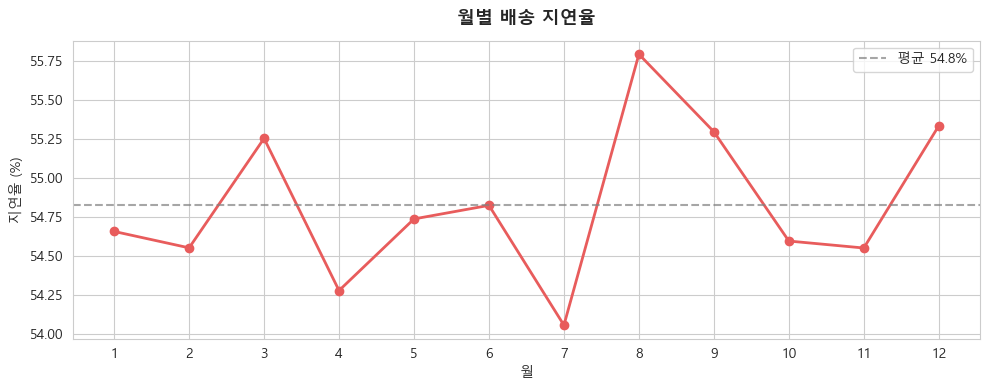

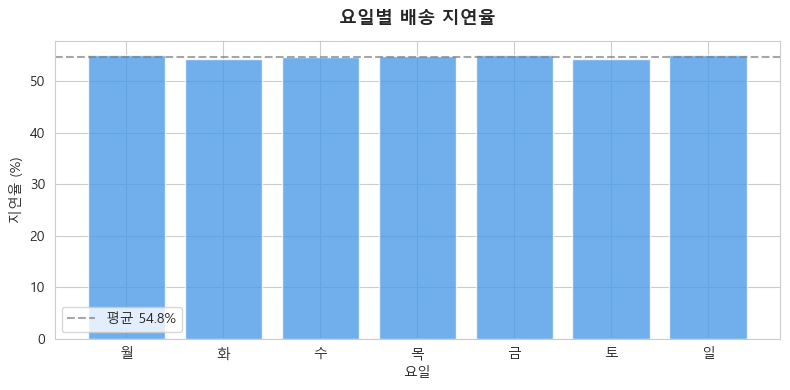

In [8]:
# 월별 지연율 확인 — 계절성이 있는지 체크
monthly_delay = df.groupby('order_month')['Late_delivery_risk'].mean() * 100

plt.figure(figsize=(10, 4))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o', color='#E85C5C', linewidth=2)
plt.axhline(y=monthly_delay.mean(), color='gray', linestyle='--', alpha=0.7, label=f'평균 {monthly_delay.mean():.1f}%')
plt.title('월별 배송 지연율', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('월')
plt.ylabel('지연율 (%)')
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

# 요일별 지연율
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
weekday_delay = df.groupby('order_weekday')['Late_delivery_risk'].mean() * 100
weekday_delay.index = [weekday_map[i] for i in weekday_delay.index]

plt.figure(figsize=(8, 4))
plt.bar(weekday_delay.index, weekday_delay.values, color='#4C9BE8', alpha=0.8)
plt.axhline(y=weekday_delay.mean(), color='gray', linestyle='--', alpha=0.7, label=f'평균 {weekday_delay.mean():.1f}%')
plt.title('요일별 배송 지연율', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('요일')
plt.ylabel('지연율 (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. 범주형 변수 인코딩

머신러닝 모델은 문자열을 처리하지 못한다.  
범주형 변수를 숫자로 변환해야 한다.

- **Label Encoding**: 순서가 있는 변수 (배송 방식 등)
- **One-Hot Encoding**: 순서가 없는 변수 (마켓, 고객 유형 등)

In [9]:
# 현재 범주형 컬럼 확인
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('범주형 컬럼 목록:')
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f'  - {col}: {unique_count}개 고유값')

범주형 컬럼 목록:
  - Type: 4개 고유값
  - Customer Segment: 3개 고유값
  - Category Name: 50개 고유값
  - Department Name: 11개 고유값
  - Market: 5개 고유값
  - Order Region: 23개 고유값
  - Order Status: 9개 고유값
  - Shipping Mode: 4개 고유값


In [10]:
# safe_cols 선택 단계에서 고유값 과다 컬럼은 이미 제외됐음
# (Order City, Order State, Customer City 등은 safe_cols에 포함하지 않았음)

# 현재 범주형 컬럼 확인
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('인코딩 대상 범주형 컬럼:')
for col in cat_cols:
    print(f'  - {col}: {df[col].unique()[:5]} ...')

인코딩 대상 범주형 컬럼:
  - Type: <ArrowStringArray>
['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT']
Length: 4, dtype: str ...
  - Customer Segment: <ArrowStringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str ...
  - Category Name: <ArrowStringArray>
['Sporting Goods', 'Cleats', 'Shop By Sport', 'Women's Apparel',
 'Electronics']
Length: 5, dtype: str ...
  - Department Name: <ArrowStringArray>
['Fitness', 'Apparel', 'Golf', 'Footwear', 'Outdoors']
Length: 5, dtype: str ...
  - Market: <ArrowStringArray>
['Pacific Asia', 'USCA', 'Africa', 'Europe', 'LATAM']
Length: 5, dtype: str ...
  - Order Region: <ArrowStringArray>
['Southeast Asia', 'South Asia', 'Oceania', 'Eastern Asia', 'West Asia']
Length: 5, dtype: str ...
  - Order Status: <ArrowStringArray>
['COMPLETE', 'PENDING', 'CLOSED', 'PENDING_PAYMENT', 'CANCELED']
Length: 5, dtype: str ...
  - Shipping Mode: <ArrowStringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str ...


In [11]:
# One-Hot Encoding 적용
# drop_first=True: 첫 번째 더미 변수를 제거해서 다중공선성 방지
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'인코딩 전: {df.shape[1]}컬럼')
print(f'인코딩 후: {df_encoded.shape[1]}컬럼')
print()

# bool 타입 컬럼을 int(0/1)로 변환 — 일부 모델이 bool을 못 받는 경우 있음
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print('인코딩 완료')
print(f'최종 데이터 타입 확인:')
print(df_encoded.dtypes.value_counts())

인코딩 전: 26컬럼
인코딩 후: 119컬럼

인코딩 완료
최종 데이터 타입 확인:
int64      105
float64     10
int32        4
Name: count, dtype: int64


---
## 6. 이상치 확인

수치형 핵심 변수에 비정상적인 값이 있는지 확인한다.

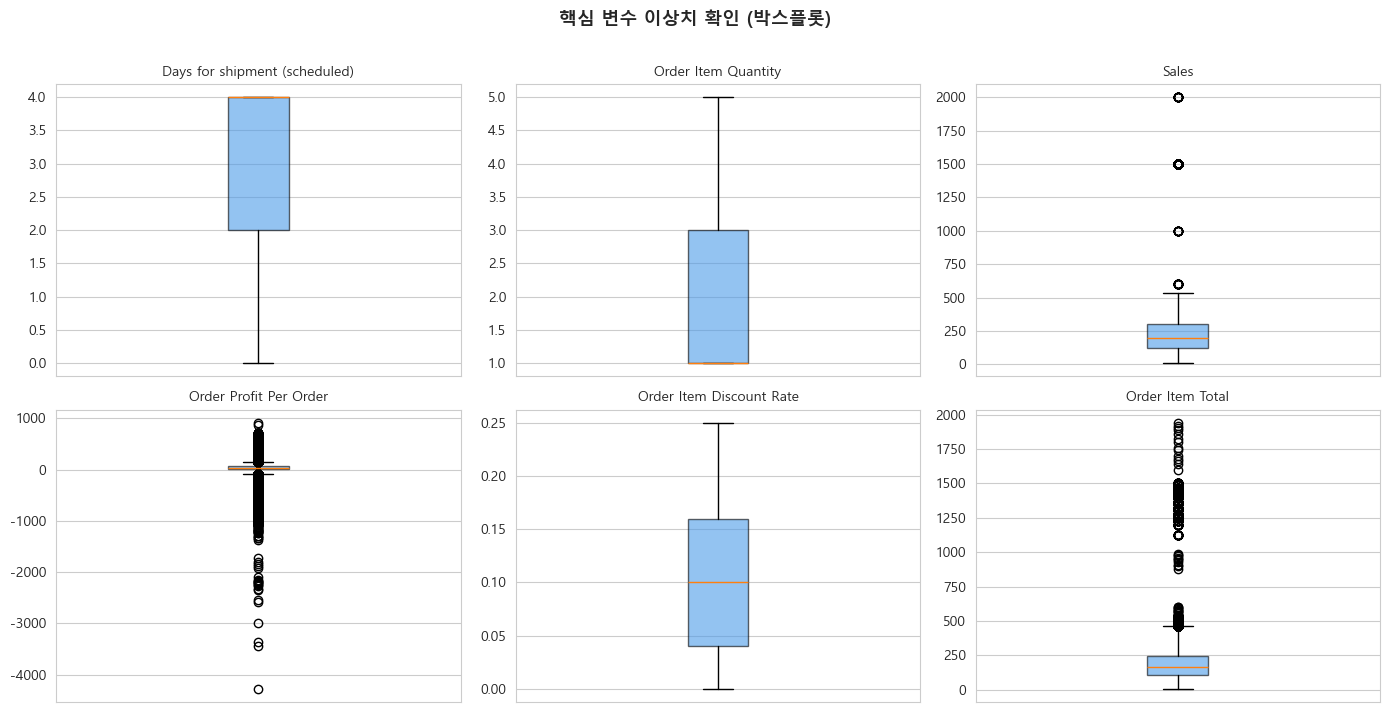

In [12]:
# 핵심 수치형 변수만 선택해서 박스플롯으로 이상치 시각화
# (누수 제거로 Days for shipping real, shipping_delay는 없음)
check_cols = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Sales',
    'Order Profit Per Order',
    'Order Item Discount Rate',
    'Order Item Total'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].boxplot(df_encoded[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C9BE8', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

plt.suptitle('핵심 변수 이상치 확인 (박스플롯)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# IQR 방식으로 이상치 비율 계산
# IQR = Q3 - Q1, 이 범위를 크게 벗어나는 값을 이상치로 판단
print('이상치 비율 (IQR 기준):')
for col in check_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    outlier_ratio = outlier_count / len(df_encoded) * 100
    print(f'  {col}: {outlier_count:,}건 ({outlier_ratio:.1f}%)')

print()
print('[판단]')
print('Sales, Order Profit에 이상치가 있지만 실제 거래 데이터 특성상 자연스러운 분포')
print('이상치 제거 없이 그대로 모델링에 사용해도 무방')

이상치 비율 (IQR 기준):
  Days for shipment (scheduled): 0건 (0.0%)
  Order Item Quantity: 0건 (0.0%)
  Sales: 488건 (0.3%)
  Order Profit Per Order: 18,942건 (10.5%)
  Order Item Discount Rate: 0건 (0.0%)
  Order Item Total: 1,943건 (1.1%)

[판단]
Sales, Order Profit에 이상치가 있지만 실제 거래 데이터 특성상 자연스러운 분포
이상치 제거 없이 그대로 모델링에 사용해도 무방


---
## 7. 최종 데이터셋 저장

In [14]:
import os

# 저장 경로 생성
os.makedirs('../data/processed', exist_ok=True)

# 전처리 완료된 데이터 저장
save_path = '../data/processed/data_preprocessed.csv'
df_encoded.to_csv(save_path, index=False)

print('전처리 완료 요약')
print('='*45)
print(f'원본 데이터  : 180,519행 × 53컬럼')
print(f'최종 데이터  : {df_encoded.shape[0]:,}행 × {df_encoded.shape[1]}컬럼')
print(f'저장 위치    : {save_path}')
print('='*45)
print()
print('주요 처리 내역:')
print('  1. 개인정보 / 불필요 컬럼 제거')
print('  2. 데이터 누수 컬럼 제거: Delivery Status, Days for shipping (real), shipping_delay')
print('  3. 결측치 행 제거')
print('  4. 날짜 → 연/월/일/요일 파생 변수 생성')
print('  5. 주문 시점에 알 수 있는 변수 중심으로 피처 구성')
print('  6. 고유값 과다 범주형 컬럼 제거')
print('  7. One-Hot Encoding 적용')
print('  8. Order Status는 운영 변수로 제한 사용 — 사기/취소 상태는 해석 주의')
print()
print('다음 단계: 03_modeling.ipynb')

전처리 완료 요약
원본 데이터  : 180,519행 × 53컬럼
최종 데이터  : 180,519행 × 119컬럼
저장 위치    : ../data/processed/data_preprocessed.csv

주요 처리 내역:
  1. 개인정보 / 불필요 컬럼 제거
  2. 데이터 누수 컬럼 제거: Delivery Status, Days for shipping (real), shipping_delay
  3. 결측치 행 제거
  4. 날짜 → 연/월/일/요일 파생 변수 생성
  5. 주문 시점에 알 수 있는 변수 중심으로 피처 구성
  6. 고유값 과다 범주형 컬럼 제거
  7. One-Hot Encoding 적용
  8. Order Status는 운영 변수로 제한 사용 — 사기/취소 상태는 해석 주의

다음 단계: 03_modeling.ipynb


In [16]:
# 최종 데이터 미리보기
print('최종 데이터 상위 3행:')
df_encoded.head(3)

최종 데이터 상위 3행:


,Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,...,Order Status_COMPLETE,Order Status_ON_HOLD,Order Status_PAYMENT_REVIEW,Order Status_PENDING,Order Status_PENDING_PAYMENT,Order Status_PROCESSING,Order Status_SUSPECTED_FRAUD,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,4,91.250000,314.640015,13.110000,0.04,327.75,0.29,1,327.75,314.640015,...,1,0,0,0,0,0,0,0,0,1
1,4,-249.089996,311.359985,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,...,0,0,0,1,0,0,0,0,0,1
2,4,-247.779999,309.720001,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,...,0,0,0,0,0,0,0,0,0,1
